In [97]:
# import pandas as pd
# import numpy as np
# import json
# from sqlalchemy import create_engine
# from collections import defaultdict
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error, r2_score

# # Kết nối database
# engine = create_engine("sqlite:///../data/sample_strategy/sample_v4.db")

# tables = ['cardiovascular_diseases', 'air_pollution', 'alcohol_consumption', 'BMI', 'cholesterol', 'diabetes', 'glucose', 'physical_activities', 'tobacco', 'country', 'time']

# # Đọc dữ liệu
# df = pd.read_sql_query("SELECT TimeDim, y FROM NearsestSample", engine)
#                        # where TimeDim >=2010 and TimeDim <=2016", engine)
# # df.drop(columns=['id', 'x7'], inplace=True)

# # df.columns = tables

# # Xóa giá trị thiếu
# df = df.dropna()

# # Tính trung bình tỷ lệ bệnh tim mạch theo năm
# trend = df.groupby("TimeDim")["y"].mean().reset_index()

# # Sắp xếp theo năm
# trend = trend.sort_values("TimeDim")

# # Vẽ biểu đồ
# plt.figure(figsize=(10,6))
# plt.plot(trend["TimeDim"], trend["y"], marker="o")

# plt.title("Trend of Cardiovascular Disease Rate Over Time")
# plt.xlabel("Year")
# plt.ylabel("Cardiovascular Disease Rate")
# plt.grid(True)

# plt.show()

In [98]:
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
# Tiến hành import thư viện để xử lí
import pandas as pd
import numpy as np
import json
from collections import defaultdict
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [99]:
# %%
conn = sqlite3.connect("../data/sample_strategy/sample_v4.db")

# Xem các bảng trong database
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql(query, conn)
print(tables)

              name
0   NearsestSample
1  sqlite_sequence


In [100]:
# %%
df = pd.read_sql("SELECT * FROM NearsestSample", conn)
# %%
df = df[(df["TimeDim"] >= 2010) & (df["TimeDim"] <= 2015)]

df.head()

,id,y,x1,x2,x3,x4,x5,x6,x7,x8,x9,SpatialDim,TimeDim
5,6,134.9,29.965,23.820369,26.1,5.0,7.200000,7.9,NaN,24.705610,28.1,ALB,2010
16,17,136.1,56.000,11.373624,26.6,4.9,54.178596,8.4,0.18,25.515699,7.4,ALB,2015
19,20,135.9,58.052,11.438215,26.5,4.9,7.700000,8.4,0.17,25.326576,7.4,ALB,2014
29,30,135.6,481.645,22.734497,26.4,5.0,7.600000,8.3,0.18,25.150570,7.4,ALB,2013
36,37,135.2,561.071,11.987971,26.2,5.0,7.300000,8.0,NaN,17.841043,28.1,ALB,2011


In [101]:
# %%
df = df.drop(columns=["x7","SpatialDim"], errors="ignore")
tables = ['cardiovascular_diseases', 'air_pollution', 'alcohol_consumption', 'BMI', 'cholesterol', 'diabetes', 'glucose', 'physical_activities', 'tobacco', 'country', 'time']
df.columns = tables
df.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,country,time
5,6,134.9,29.965,23.820369,26.1,5.0,7.200000,7.9,24.705610,28.1,2010
16,17,136.1,56.000,11.373624,26.6,4.9,54.178596,8.4,25.515699,7.4,2015
19,20,135.9,58.052,11.438215,26.5,4.9,7.700000,8.4,25.326576,7.4,2014
29,30,135.6,481.645,22.734497,26.4,5.0,7.600000,8.3,25.150570,7.4,2013
36,37,135.2,561.071,11.987971,26.2,5.0,7.300000,8.0,17.841043,28.1,2011


In [102]:
# %%
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10956 entries, 5 to 58922
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cardiovascular_diseases  10956 non-null  int64  
 1   air_pollution            10956 non-null  float64
 2   alcohol_consumption      10890 non-null  float64
 3   BMI                      10735 non-null  float64
 4   cholesterol              10956 non-null  float64
 5   diabetes                 10956 non-null  float64
 6   glucose                  10956 non-null  float64
 7   physical_activities      10956 non-null  float64
 8   tobacco                  10956 non-null  float64
 9   country                  10956 non-null  float64
 10  time                     10956 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.0 MB


In [103]:
# %%
df.isnull().sum()

cardiovascular_diseases      0
air_pollution                0
alcohol_consumption         66
BMI                        221
cholesterol                  0
diabetes                     0
glucose                      0
physical_activities          0
tobacco                      0
country                      0
time                         0
dtype: int64

In [104]:
# %%
df = df.fillna(df.mean(numeric_only=True))

In [105]:
df.describe()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,country,time
count,10956.000000,10956.000000,1.095600e+04,10956.000000,10956.000000,10956.000000,10956.000000,10956.000000,10956.000000,10956.000000,10956.000000
mean,29478.467233,55.593244,8.290686e+03,41.429338,22.424149,2.903514,16.683322,8.657804,26.063816,23.755696,2012.500000
std,17010.339242,35.512469,3.195327e+05,19.257525,17.616987,1.426160,16.735358,4.239293,11.766169,14.737694,1.707903
min,6.000000,8.701838,0.000000e+00,2.680089,0.238787,0.800000,2.800000,2.100000,3.335438,0.000000,2010.000000
25%,14755.750000,32.768090,5.106600e+01,26.664454,7.450371,1.300000,5.694480,5.900000,17.580842,12.475000,2011.000000
50%,29470.500000,40.400000,1.937165e+02,40.181983,22.200000,3.300000,8.000000,8.000000,23.772923,23.000000,2012.500000
75%,44222.500000,62.100000,5.820095e+02,52.406960,27.200000,4.000000,20.600000,9.800000,32.636906,32.800000,2014.000000
max,58923.000000,137.500000,2.509519e+07,99.215604,92.470789,5.300000,83.102876,29.800000,69.205147,77.000000,2015.000000


In [ ]:
# Tiến hành chia dữ liệu
df_model = df.copy()
y = df_model['cardiovascular_diseases']
df_model.drop(columns=['cardiovascular_diseases', 'time'], inplace=True)
X = df_model

In [107]:
# Thử tiến hành sử dụng mô hình lý giải
def run_for_linear(X, y):
    # Ko cần chia để test
    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Coefficients:", model.coef_)
    print("Intercept:", model.intercept_)
    return model.coef_, model.intercept_

In [108]:
coef, inter = run_for_linear(X, y)

MSE: 282167706.58164513
R2: 0.0247386797014143
Coefficients: [-3.30754884e+00 -3.44858404e-04  6.35705086e+01 -1.03917436e+01
 -9.19828690e+01 -2.65456408e+01  5.28316271e+02 -1.37506092e+02]
Intercept: 26984.363477409108


In [109]:
def softmax(z):
    z_shifted = z - np.max(z)   # tránh overflow
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z)

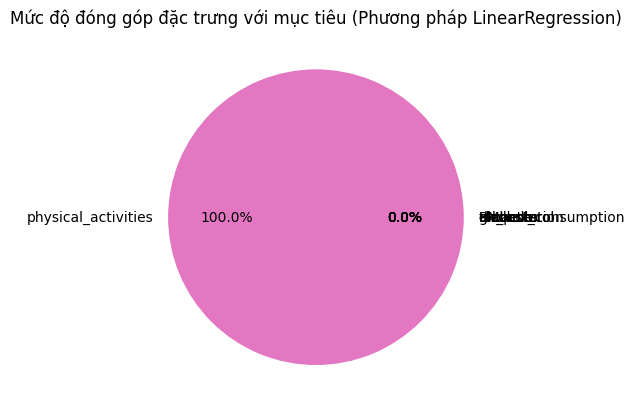

In [110]:
# Vẽ biểu đồ đối với Linear
# Thử vẽ biểu đồ đóng góp
# Biểu đồ này ko có ý nghĩa do ko giải thích được hết dữ liệu
plt.figure()
plt.pie(softmax(coef), labels=X.columns, autopct='%1.1f%%')
plt.title('Mức độ đóng góp đặc trưng với mục tiêu (Phương pháp LinearRegression)')
plt.show()

In [111]:
def run_for_random_forest(X, y):
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
    )

    model.fit(X, y)
    y_pred = model.predict(X)
    print("MSE:", mean_squared_error(y, y_pred))
    print("R2:", r2_score(y, y_pred))

    print("Feature Importances:", model.feature_importances_)
    return model.feature_importances_

In [112]:
impor = run_for_random_forest(X, y)

MSE: 15784484.579429558
R2: 0.945443801994
Feature Importances: [0.10012251 0.06958697 0.13770608 0.08863315 0.05649651 0.1135332
 0.21118289 0.2227387 ]


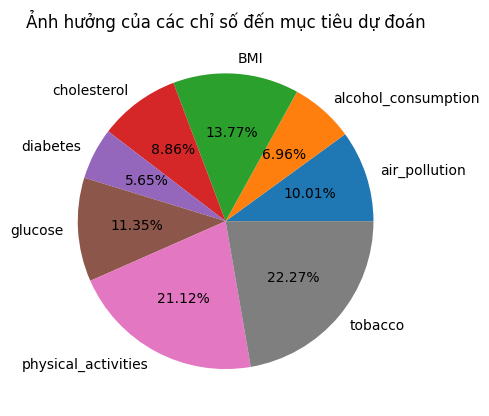

In [113]:
plt.figure()
plt.pie(impor.tolist(), labels=X.columns, autopct='%1.2f%%')
plt.title('Ảnh hưởng của các chỉ số đến mục tiêu dự đoán')
plt.show()

In [114]:
def draw_contribution(groups : dict = None, title=""):
    # Tiến hành tiền xử lí sơ sơ
    if groups is None:
        return

    mapping = dict()
    values = defaultdict(float)
    # Tạo bảng ánh xạ để hiển thị dữ liệu
    for name, comp in groups.items():
        for c in comp:
            mapping[c] = name

    # Định dạng của groups 
    # str --> tên groups
    for col, val in zip(X.columns, impor.tolist()):
        values[mapping[col]] += val

    # Thử vẽ biểu đồ đóng góp
    plt.figure()
    plt.pie(values.values(), labels=values.keys(), autopct='%1.2f%%')
    plt.title(title)
    plt.show()

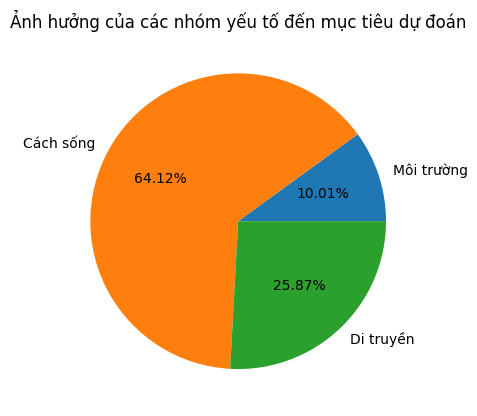

In [115]:
draw_contribution(groups={
    'Cách sống' : ['physical_activities', 'tobacco', 'alcohol_consumption', 'BMI'],
    'Môi trường' : ['air_pollution'],
    'Di truyền' : ['cholesterol', 'diabetes', 'glucose']
}, title="Ảnh hưởng của các nhóm yếu tố đến mục tiêu dự đoán")

In [116]:
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
# %%===============================================================================
scaler = StandardScaler()
features = [
    "air_pollution",
    "alcohol_consumption",
    "BMI",
    "cholesterol",
    "diabetes",
    "glucose",
    "physical_activities",
    "tobacco"
]
# Chỉ chuẩn hóa các cột số
# numeric_cols = df.select_dtypes(include=np.number).columns

df_scaled = df.copy()
df_scaled[features] = scaler.fit_transform(df[features])

df_scaled.head()

,cardiovascular_diseases,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco,country,time
5,6,2.233311,-0.025854,-0.914436,0.208663,1.470089,-0.566690,-0.178765,-0.115438,28.1,2010
16,17,2.267103,-0.025772,-1.560797,0.237046,1.399968,2.240585,-0.060816,-0.046586,7.4,2015
19,20,2.261471,-0.025766,-1.557443,0.231370,1.399968,-0.536811,-0.060816,-0.062661,7.4,2014
29,30,2.253023,-0.024440,-0.970825,0.225693,1.470089,-0.542787,-0.084406,-0.077620,7.4,2013
36,37,2.241759,-0.024191,-1.528894,0.214340,1.470089,-0.560714,-0.155175,-0.698881,28.1,2011


In [119]:
# %%
corr_matrix = df_scaled[features].corr()

corr_matrix

,air_pollution,alcohol_consumption,BMI,cholesterol,diabetes,glucose,physical_activities,tobacco
air_pollution,1.000000,0.049037,-0.073053,0.074180,0.387696,-0.079928,0.038528,0.024034
alcohol_consumption,0.049037,1.000000,-0.003418,0.001190,0.025023,-0.011489,-0.003486,0.003944
BMI,-0.073053,-0.003418,1.000000,-0.036386,-0.055325,-0.095930,-0.004755,-0.096532
cholesterol,0.074180,0.001190,-0.036386,1.000000,-0.134465,-0.137240,0.278344,0.171401
diabetes,0.387696,0.025023,-0.055325,-0.134465,1.000000,0.039834,0.058659,0.066522
glucose,-0.079928,-0.011489,-0.095930,-0.137240,0.039834,1.000000,0.170396,0.178838
physical_activities,0.038528,-0.003486,-0.004755,0.278344,0.058659,0.170396,1.000000,0.348503
tobacco,0.024034,0.003944,-0.096532,0.171401,0.066522,0.178838,0.348503,1.000000


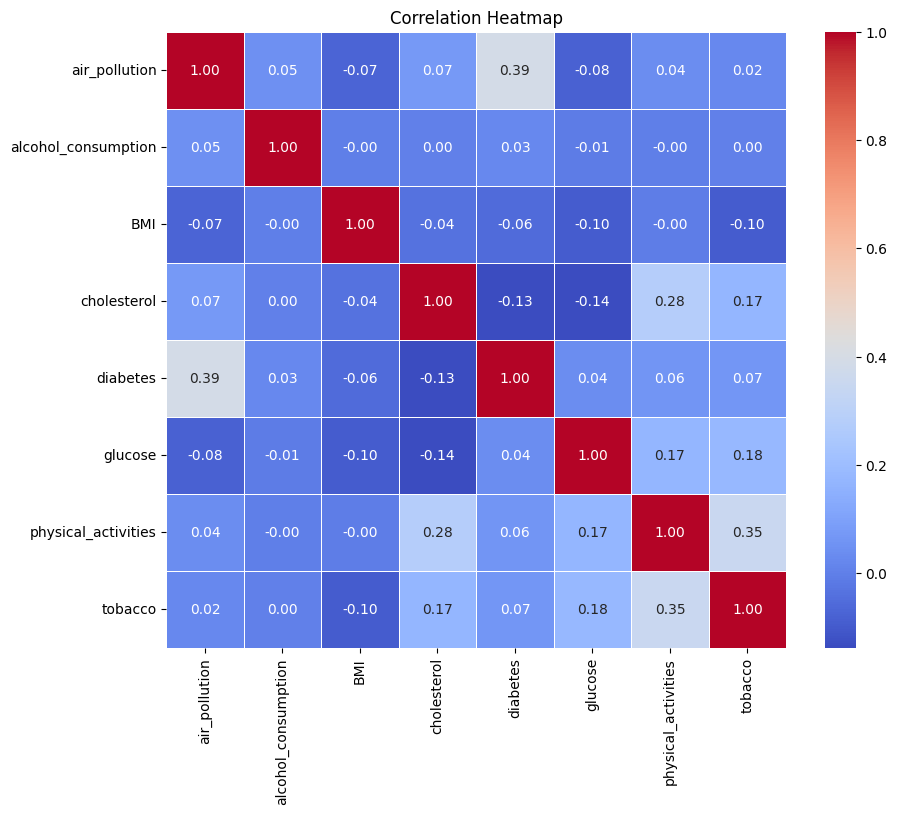

In [120]:
# %%
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()